# 🎓 Student Performance Prediction
### Beginner ML Project — EDA + Data Cleaning + Linear Regression

**Skills used:** Pandas, NumPy, Scikit-Learn, Data Cleaning, Linear Regression

This notebook walks through the full workflow:
1. Load raw (messy) data
2. Explore it (EDA)
3. Clean it
4. Train a Linear Regression model
5. Evaluate & visualize results


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Raw Data

In [2]:
df = pd.read_csv("../data/student_raw.csv")
print(df.shape)
df.head()


(1015, 8)


,hours_studied,attendance_pct,previous_scores,sleep_hours,extracurricular,parental_education,internet_access,final_score
0,2.5,79.7,60.5,6.0,No,High School,Yes,52.7
1,3.8,100.0,19.7,NaN,No,High School,Yes,50.8
2,6.0,62.7,76.8,7.0,No,Masters,Yes,74.5
3,4.5,84.2,77.3,7.3,No,Bachelors,No,67.5
4,9.7,70.6,58.0,4.5,Yes,Bachelors,No,59.3


## 2. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hours_studied       1015 non-null   float64
 1   attendance_pct      972 non-null    float64
 2   previous_scores     974 non-null    float64
 3   sleep_hours         973 non-null    float64
 4   extracurricular     1015 non-null   str    
 5   parental_education  974 non-null    str    
 6   internet_access     1015 non-null   str    
 7   final_score         1015 non-null   float64
dtypes: float64(5), str(3)
memory usage: 77.5 KB


In [4]:
df.describe()


,hours_studied,attendance_pct,previous_scores,sleep_hours,final_score
count,1015.000000,972.000000,974.000000,973.000000,1015.000000
mean,5.129852,80.694033,65.041478,6.465262,63.866897
std,2.547924,11.308949,14.398465,1.324122,9.973431
min,0.000000,44.900000,19.700000,3.000000,32.400000
25%,3.600000,72.900000,55.425000,5.500000,56.900000
50%,5.100000,80.800000,65.000000,6.500000,63.700000
75%,6.400000,88.800000,74.875000,7.400000,70.750000
max,25.000000,100.000000,100.000000,10.000000,96.500000


In [5]:
print("Missing values per column:")
df.isna().sum()


Missing values per column:


hours_studied          0
attendance_pct        43
previous_scores       41
sleep_hours           42
extracurricular        0
parental_education    41
internet_access        0
final_score            0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 15


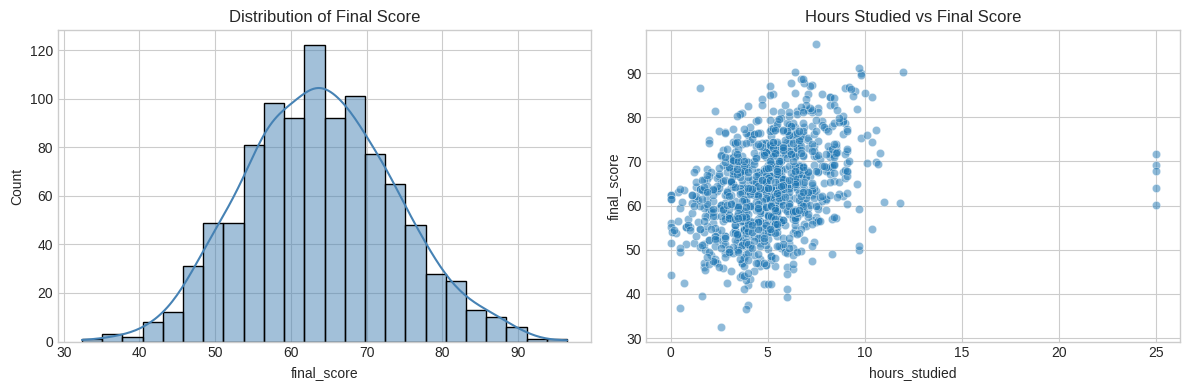

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['final_score'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Final Score')

sns.scatterplot(data=df, x='hours_studied', y='final_score', ax=axes[1], alpha=0.5)
axes[1].set_title('Hours Studied vs Final Score')
plt.tight_layout()
plt.show()


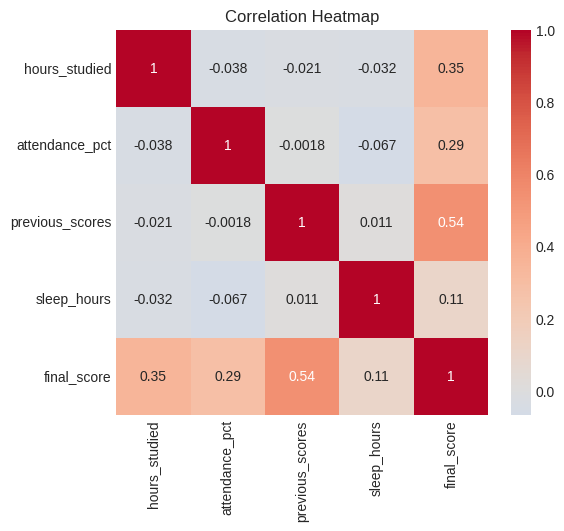

In [8]:
numeric_cols = ['hours_studied','attendance_pct','previous_scores','sleep_hours','final_score']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


## 3. Data Cleaning\n\nSee `src/data_cleaning.py` for the reusable script version. Here we walk through it interactively.

In [9]:
import sys
sys.path.append('../src')
from data_cleaning import clean_data

clean_df = clean_data(df)
clean_df.isna().sum()


🧹 Removed 15 duplicate rows
🧹 Filled 40 missing values in 'attendance_pct' with median=80.85
🧹 Filled 40 missing values in 'previous_scores' with median=64.95
🧹 Filled 40 missing values in 'sleep_hours' with median=6.5
🧹 Filled 40 missing values in 'parental_education' with mode='Bachelors'
🧹 Fixed 5 outlier values in 'hours_studied'


hours_studied         0
attendance_pct        0
previous_scores       0
sleep_hours           0
extracurricular       0
parental_education    0
internet_access       0
final_score           0
dtype: int64

In [10]:
clean_df.head()


,hours_studied,attendance_pct,previous_scores,sleep_hours,extracurricular,parental_education,internet_access,final_score
0,2.5,79.7,60.5,6.0,0,0,1,52.7
1,3.8,100.0,19.7,6.5,0,0,1,50.8
2,6.0,62.7,76.8,7.0,0,2,1,74.5
3,4.5,84.2,77.3,7.3,0,1,0,67.5
4,9.7,70.6,58.0,4.5,1,1,0,59.3


## 4. Train Linear Regression Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES = ['hours_studied','attendance_pct','previous_scores','sleep_hours',
            'extracurricular','parental_education','internet_access']
TARGET = 'final_score'

X = clean_df[FEATURES]
y = clean_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


MAE : 5.182643187966225
RMSE: 6.385169798910804
R2  : 0.648740635338768


## 5. Visualize Results

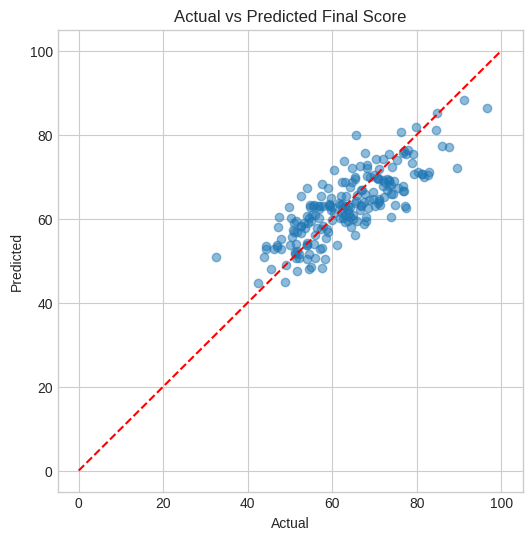

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0,100],[0,100],'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Final Score')
plt.show()


## 6. Conclusion

- Built an end-to-end ML pipeline: raw data → cleaning → modeling → evaluation
- Linear Regression achieves a reasonable R² given the noise in real-world-style data
- `previous_scores`, `hours_studied`, and `attendance_pct` are the strongest predictors
- Next steps: try Ridge/Lasso regression, Random Forest, or polynomial features
